In [45]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab, Ubuntu 등)
    # 나눔고딕이 설치되어 있어야 합니다. 없으면 'sudo apt-get install fonts-nanum' 실행
    plt.rc('font', family='NanumGothic')

#### 패키지 확인

In [46]:
fish = pd.read_csv('Fish.csv')
fish.head(2)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.52,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.48,4.3056


##### Feature
- Species: 생선의 종류 (타깃 데이터)
- Weight: 생선의 무게 (g 단위)
- Length1: 수직 길이 (Vertical length, cm)
- Length2: 대각선 길이 (Diagonal length, cm) — 보통 교재에서 '길이'로 사용하는 대표 값입니다.
- Length3: 전장 / 총 길이 (Cross length, cm)
- Height: 생선의 높이 (상하 두께, cm)
- Width: 생선의 너비 (좌우 폭, cm)

In [47]:
fish['Species'].unique()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

In [48]:
# 도미, 빙어 추출하기
fish_df = fish[fish['Species'].isin(['Bream', 'Smelt'])]
df = fish_df.copy()
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [49]:
df['Target'] = [ 1 if f == 'Bream' else 0 for f in df['Species']]
# df['target'] = df['Species'].map({'Bream': 1, 'Smelt': 0})

In [50]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Target
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,1
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,1
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,1
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,1
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,1


##### fish_data, fish_target 구성

In [61]:
fish_data = df.iloc[:, 1:-1]
fish_target = df.iloc[:,[-1]]


#### 산점도 시각화

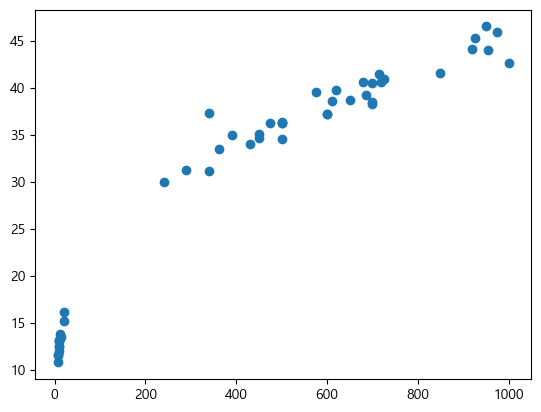

In [65]:
plt.scatter(fish_data['Weight'], fish_data['Length3'])
plt.show()

#### KNeighborsClassifier 학습

In [67]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

# 학습
kn.fit(fish_data, fish_target)

d:\study-flat\ml-c1\ml01\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
# 예측
print(kn.predict([[290.0, 24.0, 26.3, 31.2, 12.4800, 4.3056]]))

# 평가
print(kn.score(fish_data, fish_target))

[1]
1.0


d:\study-flat\ml-c1\ml01\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### train_test_split

In [83]:
x_data = df.iloc[:, 1:-1].to_numpy()
y_data = df['Target'].to_numpy()

In [84]:
y_data

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [85]:
from sklearn.model_selection import train_test_split

# 트레인 테스트 분류
train_X, test_x, train_Y, test_y = train_test_split(
    x_data, y_data, random_state=42
)

In [86]:
k = KNeighborsClassifier()

# 훈련
k.fit(train_X, train_Y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [87]:
print('훈련 : ', k.score(train_X, train_Y))
print('테스트 : ', k.score(test_x, test_y))

훈련 :  1.0
테스트 :  1.0


### 타이타닉

In [110]:
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(TITANIC_URL)
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [111]:
print(titanic.shape)                # (891, 12)
print(titanic['Survived'].value_counts())

(891, 12)
Survived
0    549
1    342
Name: count, dtype: int64


In [112]:
print(titanic.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [113]:
tdf = titanic[['Sex', 'Pclass', 'Fare', 'Survived']]
tdf.head(2)

,Sex,Pclass,Fare,Survived
0,male,3,7.2500,0
1,female,1,71.2833,1


In [115]:
df = tdf.copy()

In [118]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pclass를 문자열로 변환(pd.get_dummies가 범주형으로 인식)
df['Pclass'] = df['Pclass'].astype(str)

# Sex, Pclass 원핫 인코딩
# drop_first = True , 'Sex_male'이 1이면 female는 자동으로 0
df_encoded = pd.get_dummies(df, columns=['Sex','Pclass'], drop_first=True)

# Fare 컬럼 StandarScaler
scaler = StandardScaler()
df_encoded['Fare'] = scaler.fit_transform(df_encoded[['Fare']])

print(df_encoded.head())

       Fare  Survived  Sex_male  Pclass_2  Pclass_3
0 -0.502445         0      True     False      True
1  0.786845         1     False     False     False
2 -0.488854         1     False     False      True
3  0.420730         1     False     False     False
4 -0.486337         0      True     False      True


In [119]:
x_data = df_encoded.drop(columns=['Survived'])
y_data = df_encoded['Survived']

In [121]:
x_train, x_text, y_train, y_test = train_test_split(
    x_data, y_data, random_state=42
)

In [122]:
knkn = KNeighborsClassifier()
knkn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [124]:
print("훈련:", knkn.score(x_train, y_train))
print("테스트:", knkn.score(x_text, y_test))

훈련: 0.8502994011976048
테스트: 0.8071748878923767


   - Pclass & Fare(재력과 사회적 지위)
   - Cabin : 결측치가 과반수이기 때문에 제외
   - Age : Null 때문에 버렸지만 Median이나 평균값으로 채우기 생각해볼 것
   - 가족수 : 차후 보정( 대가족보다 가족수가 적은 쪽이 생존률 up )

In [125]:
titanic_df = titanic[['Sex', 'Pclass', 'Fare', 'Age', 'SibSp', 'Parch', 'Survived']].copy()

# 나이 결측치 처리
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

# 가족수 피처 생성
# 형제/배우자 + 부모/자식 + 나 자신(1)
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

# 가족수 중복 방지 SibSp, Parch 삭제
titanic_df = titanic_df.drop(columns=['SibSp', 'Parch'])

# Pclass 타입 변환(원핫 인코딩용)
titanic_df['Pclass'] = titanic_df['Pclass'].astype(str)

# 범주형 피처 원핫 인코딩
titanic_encoded = pd.get_dummies(titanic_df, columns=['Sex', 'Pclass'], drop_first=True)

# 수치형 피처 스케일링
t_scaler = StandardScaler()
numerical_cols = ['Fare', 'Age', 'FamilySize']

# 여러 컬럼을 한번에 스케일링
titanic_encoded[numerical_cols] = t_scaler.fit_transform(titanic_encoded[numerical_cols])

print(titanic_encoded.head())



       Fare       Age  Survived  FamilySize  Sex_male  Pclass_2  Pclass_3
0 -0.502445 -0.565736         0    0.059160      True     False      True
1  0.786845  0.663861         1    0.059160     False     False     False
2 -0.488854 -0.258337         1   -0.560975     False     False      True
3  0.420730  0.433312         1    0.059160     False     False     False
4 -0.486337  0.433312         0   -0.560975      True     False      True


In [131]:
t_x = titanic_encoded.drop(columns=['Survived'])
t_y = titanic_encoded['Survived']

In [132]:
tx_train, tx_test, ty_train, ty_test = train_test_split(
    t_x, t_y, random_state=42
)

kkk = KNeighborsClassifier()
kkk.fit(tx_train, ty_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [133]:
print("훈련:", kkk.score(tx_train, ty_train))
print("테스트:", kkk.score(tx_test, ty_test))

훈련: 0.8667664670658682
테스트: 0.8026905829596412


#### classification_report : 평가 종합

In [ ]:
from sklearn.metrics import classification_report

# 테스트 데이터로 예측값 생성
ty_pred = kkk.predict(tx_test)

# 평가지표 리포트 출력
print(classification_report(ty_test, ty_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       134
           1       0.76      0.73      0.75        89

    accuracy                           0.80       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



- 정밀도(Precision): 모델이 '생존(1)'이라고 예측한 사람들 중 실제 생존자의 비율
- 재현율(Recall): 실제 '생존(1)'한 사람들 중 모델이 맞춘 비율
- F1-스코어: 정밀도와 재현율의 균형을 나타내는 조화 평균 지표 (데이터 불균형이 있을 때 정확도보다 훨씬 중요함)

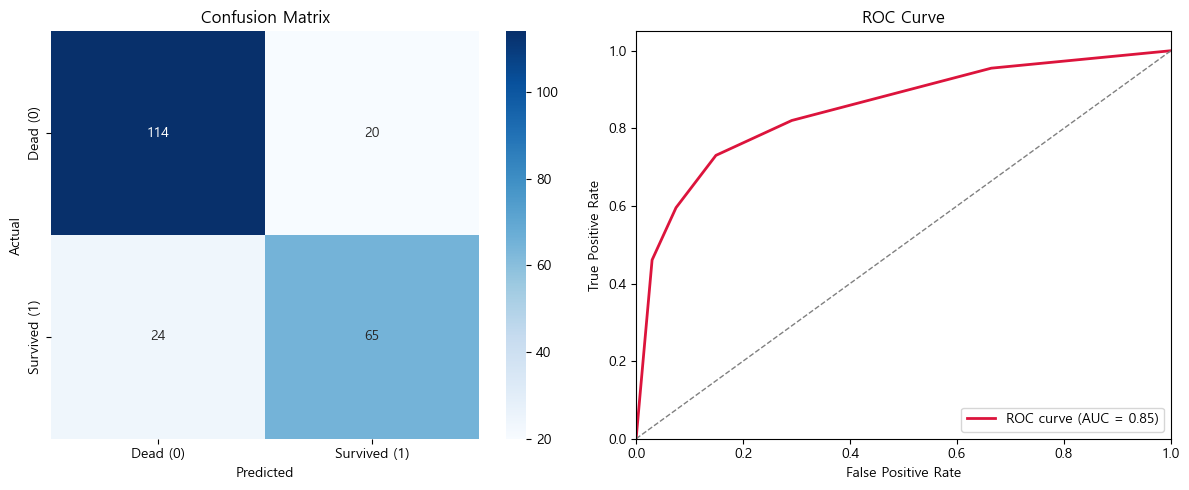

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. 테스트 데이터 예측값 및 예측 확률 구하기
ty_pred = kkk.predict(tx_test)
ty_pred_proba = kkk.predict_proba(tx_test)[:, 1] # ROC 곡선용 확률값

# 2. 시각화 그리기 (오차 행렬 & ROC 곡선)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# [왼쪽] 오차 행렬 히트맵
cm = confusion_matrix(ty_test, ty_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Dead (0)', 'Survived (1)'],
            yticklabels=['Dead (0)', 'Survived (1)'])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# [오른쪽] ROC 곡선
fpr, tpr, _ = roc_curve(ty_test, ty_pred_proba)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()

- 오차 행렬 (Confusion Matrix) 히트맵모델이 생존자를 사망자로 잘못 예측했는지, 혹은 사망자를 생존자로 잘못 예측했는지 격자 형태로 정확한 인원수를 보여줍니다
- ROC 곡선 및 AUC (ROC Curve & AUC)분류 기준(임계값)을 바꿀 때 모델이 얼마나 안정적으로 맞추는지 나타내는 곡선입니다. 그래프 아래 면적인 $AUC$ 값이 $1$에 가까울수록 아주 훌륭한 모델임을 뜻합니다.

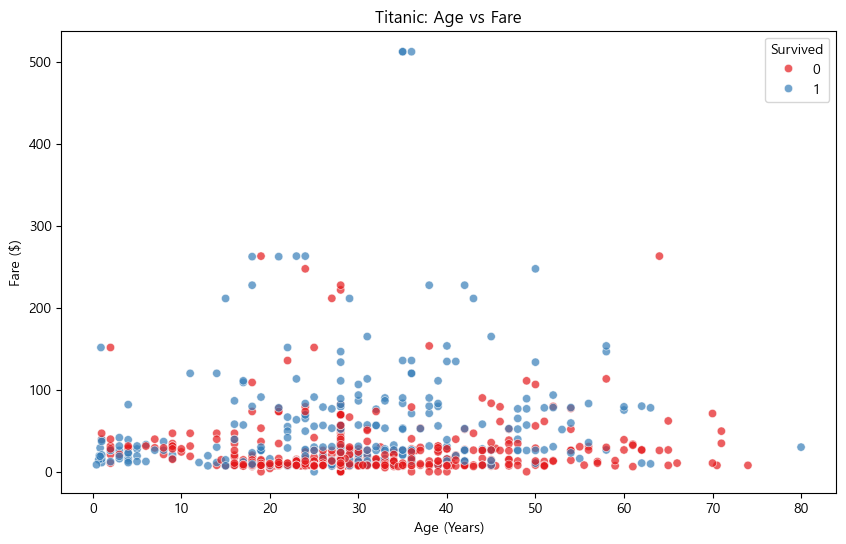

In [137]:
# Age와 Fare의 분포

plt.figure(figsize=(10, 6))
# hue='Survived'를 주어 생존자는 파란색, 사망자는 빨간색 등으로 구분합니다.
sns.scatterplot(data=titanic_df, x='Age', y='Fare', hue='Survived', palette='Set1', alpha=0.7)

plt.title('Titanic: Age vs Fare')
plt.xlabel('Age (Years)')
plt.ylabel('Fare ($)')
plt.show()

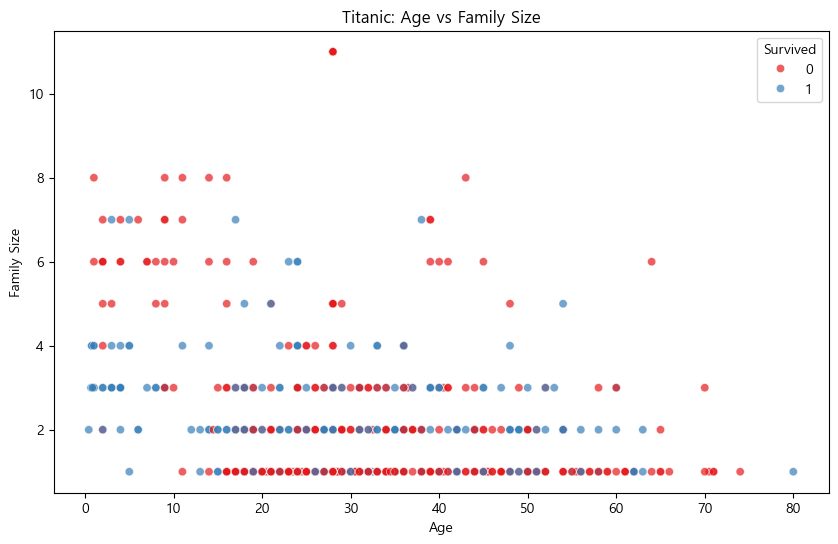

In [138]:
# Age와 Family size 분포

plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic_df, x='Age', y='FamilySize', hue='Survived', palette='Set1', alpha=0.7)

plt.title('Titanic: Age vs Family Size')
plt.xlabel('Age')
plt.ylabel('Family Size')
plt.show()